# 06 — Thailand Village Point GIS
## Point-in-Polygon, Spatial Join, Aggregation & Village Density

**กลุ่มผู้เรียน:** ปริญญาตรีปี 3–4 และปริญญาโทปี 1–2 สาขาวิทยาศาสตร์สิ่งแวดล้อม  
**ระดับ:** Intermediate  
**ข้อมูล:** Village Points + ADM1 + ADM2 + ADM3  
**เครื่องมือ:** GeoPandas · Pandas · Matplotlib · Folium · MapClassify · xyzservices

Notebook นี้เปลี่ยน geometry type จาก

$$
Polygon \rightarrow Point
$$

และตอบคำถามว่า

> ถ้าเรามี “ตำแหน่งหมู่บ้าน” GIS สามารถบอกได้หรือไม่ว่าหมู่บ้านนั้นอยู่ตำบล อำเภอ และจังหวัดใด?

แกนของบท:

$$
\boxed{
\text{Point}
\rightarrow
\text{Inspect}
\rightarrow
\text{Point-in-Polygon}
\rightarrow
\text{Spatial Join}
\rightarrow
\text{Count}
\rightarrow
\text{Density}
\rightarrow
\text{Map}
\rightarrow
\text{Interpret}
}
$$

## Learning objectives

เมื่อเรียนจบ Notebook นี้ นิสิตควรสามารถ

1. อธิบาย point geometry และความต่างจาก polygon
2. ตรวจคุณภาพข้อมูล point เช่น missing geometry, duplicate coordinates และ coordinate bounds
3. อธิบายว่าชื่อหมู่บ้านไม่จำเป็นต้องเป็น unique identifier
4. ใช้ point-in-polygon และ `gpd.sjoin()` เพื่อหา administrative unit ของหมู่บ้าน
5. ตรวจ point ที่ไม่ถูก assign เข้า polygon
6. Aggregate จำนวน village points ต่อตำบลและต่ออำเภอ
7. Join count กลับเข้าสู่ polygon
8. อธิบายความแตกต่างระหว่าง **Count** และ **Density**
9. คำนวณ village density ในหน่วย villages/km²
10. เปรียบเทียบ count map กับ density map
11. สร้าง static maps และ Folium map พร้อม Esri World Imagery
12. Export point, polygon summaries, CSV และ interactive HTML

## Recap จาก Notebook 05

Notebook 05 สร้าง hierarchy ของ polygon:

$$
ADM3 \subset ADM2 \subset ADM1
$$

Notebook 06 เพิ่ม Village Point:

$$
Village\ Point
\in
ADM3
\subset
ADM2
\subset
ADM1
$$

แนวคิดใหม่:

$$
\boxed{
Location
\rightarrow
Administrative\ Attributes
}
$$

## คำถามเปิดบท

ถ้า village dataset ไม่มี field บอกว่าจุดอยู่ตำบลไหน เราสามารถใช้ตำแหน่งตอบได้:

```text
Village point
      ↓
Which Tambon contains this point?
      ↓
Which District?
      ↓
Which Province?
```

นี่คือ workflow **point-in-polygon** ที่ใช้บ่อยมากใน Environmental GIS

## 1. ติดตั้ง libraries

In [1]:
%pip -q install geopandas folium mapclassify xyzservices pyogrio

In [2]:
from pathlib import Path
import shutil
import zipfile
import json

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import folium
import xyzservices.providers as xyz
import mapclassify

from IPython.display import display

print("GeoPandas  :", gpd.__version__)
print("Pandas     :", pd.__version__)
print("Folium     :", folium.__version__)
print("MapClassify:", mapclassify.__version__)

GeoPandas  : 1.2.0
Pandas     : 2.2.3
Folium     : 0.20.0
MapClassify: 2.10.0


## 2. Font ภาษาไทย — Sarabun

In [3]:
FONT_URL = (
    "https://raw.githubusercontent.com/"
    "google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf"
)

FONT_FILE = Path("/content/Sarabun-Regular.ttf")

if not FONT_FILE.exists():
    response = requests.get(FONT_URL, timeout=60)
    response.raise_for_status()
    FONT_FILE.write_bytes(response.content)

mpl.font_manager.fontManager.addfont(str(FONT_FILE))

font_name = mpl.font_manager.FontProperties(
    fname=str(FONT_FILE)
).get_name()

mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

print("Thai font ready:", font_name)

Thai font ready: Sarabun


## 3. Workspace

In [4]:
DATA_DIR = Path("/content/gis06_data")
OUTPUT_DIR = Path("/content/gis06_outputs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data folder   :", DATA_DIR)
print("Output folder :", OUTPUT_DIR)

Data folder   : /content/gis06_data
Output folder : /content/gis06_outputs


## 4. Download helper

In [5]:
def download_and_extract_zip(url, zip_name, extract_name):
    zip_path = DATA_DIR / zip_name
    extract_dir = DATA_DIR / extract_name

    if not zip_path.exists():
        response = requests.get(url, timeout=120)
        response.raise_for_status()
        zip_path.write_bytes(response.content)

    if extract_dir.exists():
        shutil.rmtree(extract_dir)

    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    shp_files = list(extract_dir.rglob("*.shp"))

    if not shp_files:
        raise FileNotFoundError(f"ไม่พบ .shp ใน {zip_name}")

    print("ZIP      :", zip_path)
    print("Shapefile:", shp_files[0])

    return shp_files[0]

## 5. Field helper

In [6]:
def find_column(gdf, candidates, required=False):
    lookup = {str(c).upper(): c for c in gdf.columns}

    for candidate in candidates:
        if candidate.upper() in lookup:
            return lookup[candidate.upper()]

    if required:
        raise KeyError(
            "ไม่พบ field ที่คาดไว้: "
            + ", ".join(candidates)
            + "\nFields จริง: "
            + ", ".join(map(str, gdf.columns))
        )

    return None

# Part A — Load Village Point Data

## 6. Download TH_VILLAGE2012

In [7]:
VILLAGE_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/village/TH_VILLAGE2012.zip"
)

village_shp = download_and_extract_zip(
    VILLAGE_URL,
    "TH_VILLAGE2012.zip",
    "TH_VILLAGE2012"
)

ZIP      : /content/gis06_data/TH_VILLAGE2012.zip
Shapefile: /content/gis06_data/TH_VILLAGE2012/TH_VILLAGE2012.shp


## 7. Read Village Shapefile

In [8]:
village = gpd.read_file(
    village_shp,
    encoding="UTF-8"
)

print("Village features:", len(village))
print("CRS:", village.crs)
print("Columns:")
print(list(village.columns))

display(village.head())

Village features: 65213
CRS: EPSG:4326
Columns:
['VILL_', 'VILL_ID', 'NAME', 'TYPE', 'ADM_ID', 'AMP_ID', 'PRV_ID', 'TAM_NAME', 'AMP_NAME', 'PRV_NAME', 'MAIN_ID', 'geometry']


,VILL_,VILL_ID,NAME,TYPE,ADM_ID,AMP_ID,PRV_ID,TAM_NAME,AMP_NAME,PRV_NAME,MAIN_ID,geometry
0,1,1,บ้านท่าลานเตียน,v,1090202,10902,109,ท่าฉนวน,มโนรมย์,ชัยนาท,1090001,POINT (100.11985 15.41106)
1,2,4,บ้านหนองสะแก,v,1090202,10902,109,ท่าฉนวน,มโนรมย์,ชัยนาท,1090004,POINT (100.11425 15.40837)
2,3,5,บ้านหัวยาง,v,1090202,10902,109,ท่าฉนวน,มโนรมย์,ชัยนาท,1090005,POINT (100.11983 15.40744)
3,4,6,บ้านสะพานหิน,v,1090202,10902,109,ท่าฉนวน,มโนรมย์,ชัยนาท,1090006,POINT (100.10213 15.40663)
4,5,9,บ้านทุ่งประพาส,v,1090202,10902,109,ท่าฉนวน,มโนรมย์,ชัยนาท,1090009,POINT (100.09463 15.39853)


## 8. Geometry type

In [9]:
print(village.geom_type.value_counts())

Point    65213
Name: count, dtype: int64


Village layer ควรเป็น point geometry

$$
P=(x,y)
$$

หนึ่ง point แทน “ตำแหน่งหมู่บ้าน”

> จุดอาจเป็น representative location ไม่ใช่ขอบเขต settlement ทั้งหมด

# Part B — Inspect Village Attributes

## 9. สำรวจ string fields และตัวอย่างค่า

In [10]:
object_cols = [
    c for c in village.columns
    if c != "geometry"
    and village[c].dtype == "object"
]

schema_samples = []

for col in object_cols:
    vals = (
        village[col]
        .dropna()
        .astype(str)
        .head(5)
        .tolist()
    )

    schema_samples.append({
        "Field": col,
        "Example values": " | ".join(vals)
    })

display(pd.DataFrame(schema_samples))

,Field,Example values
0,NAME,บ้านท่าลานเตียน | บ้านหนองสะแก | บ้านหัวยาง | ...
1,TYPE,v | v | v | v | v
2,TAM_NAME,ท่าฉนวน | ท่าฉนวน | ท่าฉนวน | ท่าฉนวน | ท่าฉนวน
3,AMP_NAME,มโนรมย์ | มโนรมย์ | มโนรมย์ | มโนรมย์ | มโนรมย์
4,PRV_NAME,ชัยนาท | ชัยนาท | ชัยนาท | ชัยนาท | ชัยนาท


## 10. Detect candidate fields

ชื่อ field ของ village dataset อาจต่างจาก ADM layers จึงต้อง inspect schema ก่อน

> **Field name ≠ guaranteed meaning**

In [11]:
village_name = find_column(
    village,
    [
        "VILL_NAME", "VIL_NAME", "VILLAGE",
        "VILL_NAM_T", "MOO_NAME", "BAN_NAME",
        "TAM_NAME"
    ],
    required=False
)

village_code = find_column(
    village,
    [
        "VILL_CODE", "VIL_CODE", "VILLAGE_ID",
        "MOO_CODE", "VILL_ID", "OBJECTID"
    ],
    required=False
)

village_province_field = find_column(
    village,
    [
        "ADM1_TH", "PROV_NAME", "PROV_NAM_T",
        "PROVINCE", "CHANGWAT"
    ],
    required=False
)

village_district_field = find_column(
    village,
    [
        "ADM2_TH", "AMP_NAME", "AMP_NAM_T",
        "AMPHOE", "DISTRICT"
    ],
    required=False
)

village_tambon_field = find_column(
    village,
    [
        "ADM3_TH", "TAM_NAME", "TAM_NAM_T",
        "TAMBON", "SUBDIST"
    ],
    required=False
)

print("Village name candidate :", village_name)
print("Village code candidate :", village_code)
print("Province field         :", village_province_field)
print("District field         :", village_district_field)
print("Tambon field           :", village_tambon_field)

Village name candidate : TAM_NAME
Village code candidate : VILL_ID
Province field         : None
District field         : AMP_NAME
Tambon field           : TAM_NAME


## 11. Inspect detected fields

In [12]:
inspect_fields = [
    f for f in [
        village_code,
        village_name,
        village_province_field,
        village_district_field,
        village_tambon_field
    ]
    if f is not None
]

inspect_fields = list(dict.fromkeys(inspect_fields))

if inspect_fields:
    display(
        village[
            inspect_fields + ["geometry"]
        ].head(15)
    )
else:
    print("ไม่พบ candidate fields อัตโนมัติ")

,VILL_ID,TAM_NAME,AMP_NAME,geometry
0,1,ท่าฉนวน,มโนรมย์,POINT (100.11985 15.41106)
1,4,ท่าฉนวน,มโนรมย์,POINT (100.11425 15.40837)
2,5,ท่าฉนวน,มโนรมย์,POINT (100.11983 15.40744)
3,6,ท่าฉนวน,มโนรมย์,POINT (100.10213 15.40663)
4,9,ท่าฉนวน,มโนรมย์,POINT (100.09463 15.39853)
5,10,ท่าฉนวน,มโนรมย์,POINT (100.14494 15.39737)
6,12,ท่าฉนวน,มโนรมย์,POINT (100.11045 15.39574)
7,15,ท่าฉนวน,มโนรมย์,POINT (100.14024 15.39016)
8,18,ท่าฉนวน,มโนรมย์,POINT (100.10948 15.38761)
9,20,ท่าฉนวน,มโนรมย์,POINT (100.10481 15.38582)


# Part C — Point Data Quality Control

## 12. Missing / Empty / Invalid Geometry

In [13]:
point_qc = pd.DataFrame({
    "Count": [
        len(village),
        village.geometry.isna().sum(),
        village.geometry.is_empty.sum(),
        (~village.is_valid.fillna(False)).sum()
    ]
}, index=[
    "All records",
    "Missing geometry",
    "Empty geometry",
    "Invalid / unavailable"
])

display(point_qc)

,Count
All records,65213
Missing geometry,0
Empty geometry,0
Invalid / unavailable,0


## 13. Duplicate coordinates

In [14]:
print(
    "Duplicated point geometries:",
    village.geometry.duplicated().sum()
)

Duplicated point geometries: 1554


Duplicate location ไม่จำเป็นต้องเป็น error เสมอไป อาจเกิดจากหลาย records ใช้ representative coordinate เดียวกัน

## 14. Coordinate bounds

In [15]:
if village.crs is None:
    raise ValueError(
        "Village layer ไม่มี CRS — ต้องตรวจ source ก่อนวิเคราะห์"
    )

village_ll = village.to_crs("EPSG:4326")

xmin, ymin, xmax, ymax = village_ll.total_bounds

print("Longitude:", xmin, "to", xmax)
print("Latitude :", ymin, "to", ymax)

Longitude: 97.41601543816444 to 105.62863807896582
Latitude : 5.712015652661156 to 20.446052824175343


## 15. Village name ไม่ใช่ Unique ID

In [16]:
if village_name:
    unique_names = village[village_name].nunique(dropna=True)

    print("Records             :", len(village))
    print("Unique village names:", unique_names)
    print("Repeated-name gap   :", len(village) - unique_names)
else:
    print("ไม่พบ village-name field อัตโนมัติ")

Records             : 65213
Unique village names: 5063
Repeated-name gap   : 60150


ชื่อหมู่บ้านซ้ำกันได้

$$
\boxed{
Name \neq Unique\ Identifier
}
$$

ถ้ามี village code ควรใช้ code เป็น key

# Part D — National Village Distribution

## 16. Load Province boundary

In [17]:
ADM1_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm1/tha_adm1_province_shapefile.zip"
)

adm1_shp = download_and_extract_zip(
    ADM1_URL,
    "tha_adm1_province_shapefile.zip",
    "tha_adm1"
)

province = gpd.read_file(
    adm1_shp,
    encoding="UTF-8"
)

p_adm1_code = find_column(
    province,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

p_adm1_th = find_column(
    province,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

ZIP      : /content/gis06_data/tha_adm1_province_shapefile.zip
Shapefile: /content/gis06_data/tha_adm1/tha_adm1_province.shp


## 17. National point map

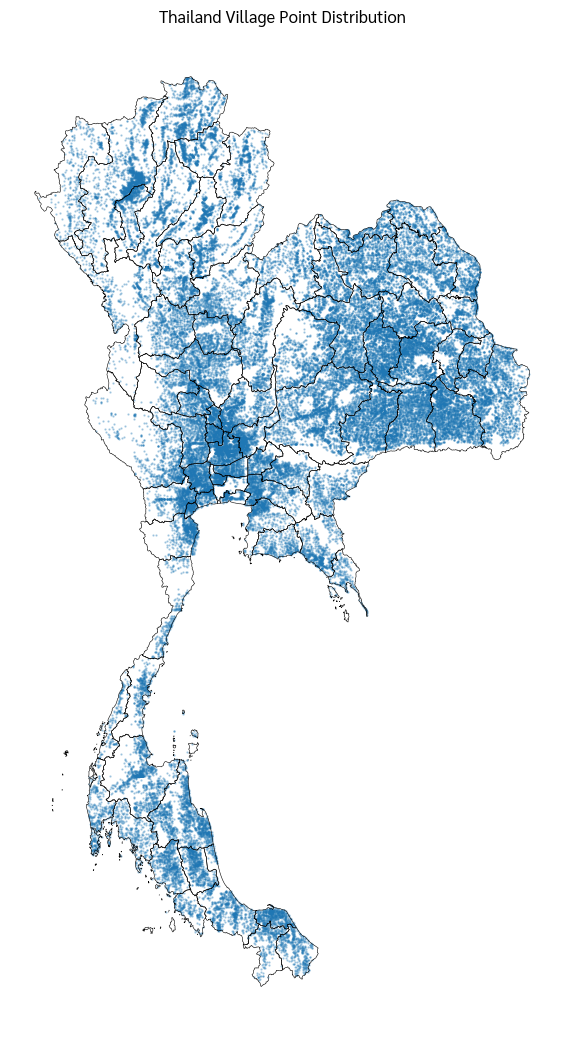

In [18]:
fig, ax = plt.subplots(figsize=(9, 13))

province.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.4
)

village_ll.plot(
    ax=ax,
    markersize=0.4,
    alpha=0.35
)

ax.set_title("Thailand Village Point Distribution")
ax.set_axis_off()

plt.show()

## 18. Overplotting

เมื่อจุดจำนวนมากซ้อนกัน:

```text
many points
↓
overlap
↓
dark clusters
```

จึงไม่ควรตีความความเข้มของกลุ่มจุดเป็นค่าตัวแปรโดยตรง

# Part E — Load ADM2 + ADM3

## 19. Download District and Tambon

In [19]:
ADM2_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tha_adm2/tha_admbnda_adm2_shapefile.zip"
)

ADM3_URL = (
    "https://raw.githubusercontent.com/"
    "nattaponm/thailand_gis_prasertcbs/"
    "main/tambon_simplify/tha_admbnda_adm3_rtsd_20220121.zip"
)

adm2_shp = download_and_extract_zip(
    ADM2_URL,
    "tha_admbnda_adm2_shapefile.zip",
    "tha_adm2"
)

adm3_shp = download_and_extract_zip(
    ADM3_URL,
    "tha_admbnda_adm3_rtsd_20220121.zip",
    "tha_adm3"
)

district = gpd.read_file(adm2_shp, encoding="UTF-8")
tambon = gpd.read_file(adm3_shp, encoding="UTF-8")

print("District features:", len(district))
print("Tambon features  :", len(tambon))

ZIP      : /content/gis06_data/tha_admbnda_adm2_shapefile.zip
Shapefile: /content/gis06_data/tha_adm2/tha_admbnda_adm2.shp
ZIP      : /content/gis06_data/tha_admbnda_adm3_rtsd_20220121.zip
Shapefile: /content/gis06_data/tha_adm3/tha_admbnda_adm3_rtsd_20220121.shp
District features: 928
Tambon features  : 7425


## 20. Detect administrative fields

In [20]:
d_adm1_code = find_column(
    district,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

d_adm2_code = find_column(
    district,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

d_adm2_th = find_column(
    district,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

t_adm1_code = find_column(
    tambon,
    ["ADM1_PCODE", "ADM1_CODE"],
    required=True
)

t_adm1_th = find_column(
    tambon,
    ["ADM1_TH", "NAME_1_TH"],
    required=True
)

t_adm2_code = find_column(
    tambon,
    ["ADM2_PCODE", "ADM2_CODE"],
    required=True
)

t_adm2_th = find_column(
    tambon,
    ["ADM2_TH", "NAME_2_TH"],
    required=True
)

t_adm3_code = find_column(
    tambon,
    ["ADM3_PCODE", "ADM3_CODE"],
    required=True
)

t_adm3_th = find_column(
    tambon,
    ["ADM3_TH", "NAME_3_TH"],
    required=True
)

print(
    "Hierarchy:",
    t_adm1_th,
    "→",
    t_adm2_th,
    "→",
    t_adm3_th
)

Hierarchy: ADM1_TH → ADM2_TH → ADM3_TH


# Part F — Focus: Phitsanulok

## 21. Query ADM1 / ADM2 / ADM3

In [21]:
phs_province = province[
    province[p_adm1_th]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
].copy()

phs_tambon = tambon[
    tambon[t_adm1_th]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
].copy()

phs_codes = (
    phs_tambon[t_adm1_code]
    .astype(str)
    .unique()
)

phs_district = district[
    district[d_adm1_code]
    .astype(str)
    .isin(phs_codes)
].copy()

print("Province:", len(phs_province))
print("District:", len(phs_district))
print("Tambon  :", len(phs_tambon))

Province: 1
District: 9
Tambon  : 93


## 22. Optional attribute query ของ village

In [22]:
phs_village_attr = None

if village_province_field:
    phs_village_attr = village[
        village[village_province_field]
        .astype(str)
        .str.contains(
            "พิษณุโลก",
            case=False,
            na=False
        )
    ].copy()

    print(
        "Attribute-selected village points:",
        len(phs_village_attr)
    )
else:
    print(
        "ไม่มี province field ที่ตรวจพบ — "
        "จะใช้ spatial query เป็นหลัก"
    )

ไม่มี province field ที่ตรวจพบ — จะใช้ spatial query เป็นหลัก


# Part G — Point-in-Polygon Spatial Join

## 23. Concept

ถ้า village point $P_i$ อยู่ใน Tambon polygon $A_j$

$$
P_i \in A_j
$$

Spatial join จะเปลี่ยน “ตำแหน่ง” ให้กลายเป็น administrative attributes

## 24. Prepare Tambon layer for join

In [23]:
tambon_for_join = tambon[
    [
        t_adm1_code,
        t_adm1_th,
        t_adm2_code,
        t_adm2_th,
        t_adm3_code,
        t_adm3_th,
        "geometry"
    ]
].copy()

tambon_for_join = tambon_for_join.rename(
    columns={
        t_adm1_code: "SP_ADM1_PCODE",
        t_adm1_th: "SP_ADM1_TH",
        t_adm2_code: "SP_ADM2_PCODE",
        t_adm2_th: "SP_ADM2_TH",
        t_adm3_code: "SP_ADM3_PCODE",
        t_adm3_th: "SP_ADM3_TH"
    }
)

## 25. Spatial Join: Village → Tambon

In [24]:
if village.crs != tambon_for_join.crs:
    village_join_source = village.to_crs(
        tambon_for_join.crs
    )
else:
    village_join_source = village.copy()

village_joined = gpd.sjoin(
    village_join_source,
    tambon_for_join,
    how="left",
    predicate="within"
)

print("Joined records:", len(village_joined))

display(
    village_joined[
        [
            "SP_ADM1_TH",
            "SP_ADM2_TH",
            "SP_ADM3_TH"
        ]
        + (
            [village_name]
            if village_name
            and village_name in village_joined.columns
            else []
        )
    ].head(15)
)

Joined records: 65213


,SP_ADM1_TH,SP_ADM2_TH,SP_ADM3_TH,TAM_NAME
0,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
1,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
2,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
3,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
4,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
5,นครสวรรค์,พยุหะคีรี,ม่วงหัก,ท่าฉนวน
6,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
7,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
8,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน
9,ชัยนาท,มโนรมย์,ท่าฉนวน,ท่าฉนวน


## 26. Unassigned village points

In [25]:
unassigned = village_joined[
    village_joined[
        "SP_ADM3_PCODE"
    ].isna()
].copy()

print("Assigned  :", village_joined["SP_ADM3_PCODE"].notna().sum())
print("Unassigned:", len(unassigned))

Assigned  : 65082
Unassigned: 131


จุดที่ไม่ถูก assign อาจเกิดจาก source year ต่างกัน, simplified boundary, coordinate error, CRS หรือจุดอยู่ใกล้ boundary

# Part H — Spatial Selection of Phitsanulok Villages

## 27. Select by spatially assigned province

In [26]:
phs_village = village_joined[
    village_joined["SP_ADM1_TH"]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
].copy()

print(
    "Village points spatially assigned to Phitsanulok:",
    len(phs_village)
)

Village points spatially assigned to Phitsanulok: 863


## 28. Attribute vs Spatial count — ถ้ามี field เดิม

In [27]:
if phs_village_attr is not None:
    print("Attribute selection:", len(phs_village_attr))
    print("Spatial selection  :", len(phs_village))
else:
    print("ไม่มี attribute selection สำหรับเปรียบเทียบ")

ไม่มี attribute selection สำหรับเปรียบเทียบ


# Part I — Optional Attribute vs Spatial Validation

## 29. Agreement

$$
Agreement(\%)=
\frac{N_{match}}{N_{assigned}}\times100
$$

In [28]:
def normalized_text(series):
    return (
        series
        .astype(str)
        .str.strip()
        .str.casefold()
    )

validation_rows = []

for level, original_field, spatial_field in [
    ("Province", village_province_field, "SP_ADM1_TH"),
    ("District", village_district_field, "SP_ADM2_TH"),
    ("Tambon", village_tambon_field, "SP_ADM3_TH"),
]:
    if original_field and original_field in village_joined.columns:
        assigned = village_joined[
            village_joined[spatial_field].notna()
        ].copy()

        matches = (
            normalized_text(assigned[original_field])
            ==
            normalized_text(assigned[spatial_field])
        )

        validation_rows.append({
            "Level": level,
            "Assigned": len(assigned),
            "Matches": int(matches.sum()),
            "Agreement_pct": (
                100 * matches.mean()
                if len(matches) > 0
                else np.nan
            )
        })

validation_table = pd.DataFrame(validation_rows)

if validation_table.empty:
    print("ไม่มี administrative source fields ที่เทียบได้")
else:
    display(validation_table.round(2))

,Level,Assigned,Matches,Agreement_pct
0,District,65082,48121,73.94
1,Tambon,65082,53447,82.12


# Part J — Village Count by Tambon

## 30. Aggregation

$$
N_j=
\sum_i I(P_i\in A_j)
$$

In [29]:
village_count_tambon = (
    village_joined[
        village_joined["SP_ADM3_PCODE"].notna()
    ]
    .groupby(
        [
            "SP_ADM1_PCODE",
            "SP_ADM1_TH",
            "SP_ADM2_PCODE",
            "SP_ADM2_TH",
            "SP_ADM3_PCODE",
            "SP_ADM3_TH"
        ],
        as_index=False
    )
    .size()
    .rename(columns={"size": "village_count"})
)

display(village_count_tambon.head(15))

,SP_ADM1_PCODE,SP_ADM1_TH,SP_ADM2_PCODE,SP_ADM2_TH,SP_ADM3_PCODE,SP_ADM3_TH,village_count
0,TH10,กรุงเทพมหานคร,TH1003,หนองจอก,TH100301,กระทุ่มราย,3
1,TH10,กรุงเทพมหานคร,TH1003,หนองจอก,TH100302,หนองจอก,1
2,TH10,กรุงเทพมหานคร,TH1003,หนองจอก,TH100303,คลองสิบ,2
3,TH10,กรุงเทพมหานคร,TH1003,หนองจอก,TH100304,คลองสิบสอง,3
4,TH10,กรุงเทพมหานคร,TH1003,หนองจอก,TH100305,โคกแฝด,2
5,TH10,กรุงเทพมหานคร,TH1005,บางเขน,TH100508,ท่าแร้ง,2
6,TH10,กรุงเทพมหานคร,TH1010,มีนบุรี,TH101001,มีนบุรี,1
7,TH10,กรุงเทพมหานคร,TH1011,ลาดกระบัง,TH101102,คลองสองต้นนุ่น,1
8,TH10,กรุงเทพมหานคร,TH1011,ลาดกระบัง,TH101106,ขุมทอง,1
9,TH10,กรุงเทพมหานคร,TH1023,หนองแขม,TH102303,หนองค้างพลู,1


## 31. Join count back to Tambon polygons

In [30]:
tambon_stats = tambon.merge(
    village_count_tambon[
        [
            "SP_ADM3_PCODE",
            "village_count"
        ]
    ].rename(
        columns={
            "SP_ADM3_PCODE": t_adm3_code
        }
    ),
    on=t_adm3_code,
    how="left"
)

tambon_stats["village_count"] = (
    tambon_stats["village_count"]
    .fillna(0)
    .astype(int)
)

print(
    "Tambons with zero joined village points:",
    (tambon_stats["village_count"] == 0).sum()
)

Tambons with zero joined village points: 559


# Part K — Village Count by District

## 32. Aggregate to ADM2

In [31]:
village_count_district = (
    village_joined[
        village_joined["SP_ADM2_PCODE"].notna()
    ]
    .groupby(
        [
            "SP_ADM1_PCODE",
            "SP_ADM1_TH",
            "SP_ADM2_PCODE",
            "SP_ADM2_TH"
        ],
        as_index=False
    )
    .size()
    .rename(columns={"size": "village_count"})
    .sort_values(
        "village_count",
        ascending=False
    )
)

display(village_count_district.head(15))

,SP_ADM1_PCODE,SP_ADM1_TH,SP_ADM2_PCODE,SP_ADM2_TH,village_count
218,TH32,สุรินทร์,TH3205,ปราสาท,302
191,TH31,บุรีรัมย์,TH3101,เมืองบุรีรัมย์,289
214,TH32,สุรินทร์,TH3201,เมืองสุรินทร์,268
393,TH44,มหาสารคาม,TH4403,โกสุมพิสัย,264
56,TH16,ลพบุรี,TH1601,เมืองลพบุรี,262
234,TH33,ศรีสะเกษ,TH3304,กันทรลักษ์,244
235,TH33,ศรีสะเกษ,TH3305,ขุขันธ์,239
399,TH44,มหาสารคาม,TH4409,วาปีปทุม,236
708,TH73,นครปฐม,TH7302,กำแพงแสน,235
665,TH67,เพชรบูรณ์,TH6703,หล่มสัก,216


## 33. Top 10 Districts by Village Count

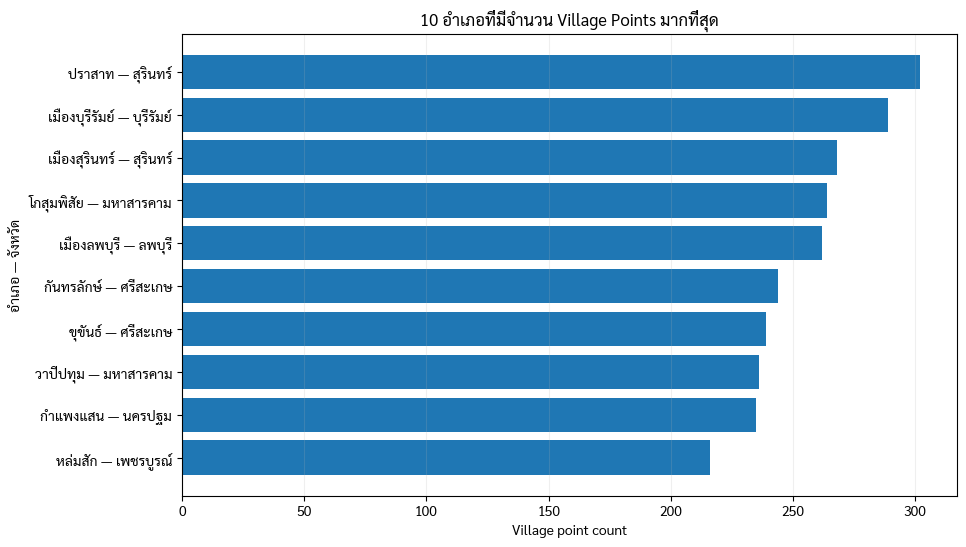

In [32]:
top10_district_count = village_count_district.head(10).copy()

plot_top10 = top10_district_count.sort_values(
    "village_count",
    ascending=True
)

labels = (
    plot_top10["SP_ADM2_TH"].astype(str)
    + " — "
    + plot_top10["SP_ADM1_TH"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(labels, plot_top10["village_count"])

ax.set_title(
    "10 อำเภอที่มีจำนวน Village Points มากที่สุด"
)
ax.set_xlabel("Village point count")
ax.set_ylabel("อำเภอ — จังหวัด")
ax.grid(axis="x", alpha=0.2)

plt.show()

จำนวน village points มาก ไม่ได้แปลว่าประชากรมาก

$$
\boxed{
Village\ count \neq Population
}
$$

# Part L — Village Density

## 34. Count vs Density

$$
D_j=
\frac{N_j}{A_j}
$$

หน่วย:

$$
villages/km^2
$$

## 35. Calculate area and density

In [33]:
tambon_stats_ea = tambon_stats.to_crs("EPSG:6933")

tambon_stats_ea["area_km2"] = (
    tambon_stats_ea.geometry.area
    / 1_000_000
)

tambon_stats_ea["village_density"] = (
    tambon_stats_ea["village_count"]
    / tambon_stats_ea["area_km2"]
)

display(
    tambon_stats_ea[
        [
            t_adm1_th,
            t_adm2_th,
            t_adm3_th,
            "village_count",
            "area_km2",
            "village_density"
        ]
    ].head(10)
)

,ADM1_TH,ADM2_TH,ADM3_TH,village_count,area_km2,village_density
0,กรุงเทพมหานคร,พระนคร,พระบรมมหาราชวัง,0,1.338205,0.0
1,กรุงเทพมหานคร,พระนคร,วังบูรพาภิรมย์,0,0.805858,0.0
2,กรุงเทพมหานคร,พระนคร,วัดราชบพิธ,0,0.208782,0.0
3,กรุงเทพมหานคร,พระนคร,สำราญราษฎร์,0,0.235054,0.0
4,กรุงเทพมหานคร,พระนคร,ศาลเจ้าพ่อเสือ,0,0.154144,0.0
5,กรุงเทพมหานคร,พระนคร,เสาชิงช้า,0,0.155260,0.0
6,กรุงเทพมหานคร,พระนคร,บวรนิเวศ,0,0.511787,0.0
7,กรุงเทพมหานคร,พระนคร,ตลาดยอด,0,0.095387,0.0
8,กรุงเทพมหานคร,พระนคร,ชนะสงคราม,0,0.362088,0.0
9,กรุงเทพมหานคร,พระนคร,บ้านพานถม,0,0.495199,0.0


## 36. Count ≠ Density

ตัวอย่าง:

```text
Tambon A
20 villages / 400 km²
= 0.05 villages/km²

Tambon B
10 villages / 50 km²
= 0.20 villages/km²
```

ดังนั้น

$$
\boxed{
Raw\ count \neq Normalized\ density
}
$$

และ Village Density ไม่ใช่ Population Density

# Part M — Phitsanulok Village Analysis

## 37. Phitsanulok Tambon statistics

In [34]:
phs_tambon_stats = tambon_stats_ea[
    tambon_stats_ea[t_adm1_th]
    .astype(str)
    .str.contains("พิษณุโลก", na=False)
].copy()

print("Phitsanulok tambons:", len(phs_tambon_stats))

display(
    phs_tambon_stats[
        [
            t_adm2_th,
            t_adm3_th,
            "village_count",
            "area_km2",
            "village_density"
        ]
    ]
    .sort_values(
        "village_density",
        ascending=False
    )
    .head(20)
    .round(3)
)

Phitsanulok tambons: 93


,ADM2_TH,ADM3_TH,village_count,area_km2,village_density
5420,เมืองพิษณุโลก,บ้านคลอง,5,8.251,0.606
5457,บางกระทุ่ม,โคกสลุด,11,20.126,0.547
5416,เมืองพิษณุโลก,ปากโทก,8,16.203,0.494
5418,เมืองพิษณุโลก,จอมทอง,8,18.127,0.441
5421,เมืองพิษณุโลก,พลายชุมพล,5,12.976,0.385
5456,บางกระทุ่ม,บ้านไร่,11,28.646,0.384
5411,เมืองพิษณุโลก,ท่าทอง,8,23.050,0.347
5422,เมืองพิษณุโลก,มะขามสูง,9,26.442,0.340
5427,นครไทย,นครไทย,12,38.191,0.314
5409,เมืองพิษณุโลก,วัดจันทร์,4,12.925,0.309


## 38. Top 10 by Village Count

In [35]:
phs_top_count = phs_tambon_stats.nlargest(
    10,
    "village_count"
).copy()

display(
    phs_top_count[
        [
            t_adm2_th,
            t_adm3_th,
            "village_count",
            "area_km2",
            "village_density"
        ]
    ].round(3)
)

,ADM2_TH,ADM3_TH,village_count,area_km2,village_density
5494,เนินมะปราง,บ้านมุง,37,233.042,0.159
5428,นครไทย,หนองกะท้าว,23,465.645,0.049
5495,เนินมะปราง,ไทรย้อย,21,87.222,0.241
5444,บางระกำ,บางระกำ,20,113.864,0.176
5489,วังทอง,วังนกแอ่น,20,666.855,0.030
5493,เนินมะปราง,ชมพู,19,486.503,0.039
5498,เนินมะปราง,เนินมะปราง,19,93.944,0.202
5441,ชาติตระการ,บ้านดง,16,348.314,0.046
5449,บางระกำ,หนองกุลา,16,152.531,0.105
5452,บางระกำ,บ่อทอง,15,48.855,0.307


## 39. Top 10 by Village Density

In [36]:
phs_top_density = phs_tambon_stats.nlargest(
    10,
    "village_density"
).copy()

display(
    phs_top_density[
        [
            t_adm2_th,
            t_adm3_th,
            "village_count",
            "area_km2",
            "village_density"
        ]
    ].round(3)
)

,ADM2_TH,ADM3_TH,village_count,area_km2,village_density
5420,เมืองพิษณุโลก,บ้านคลอง,5,8.251,0.606
5457,บางกระทุ่ม,โคกสลุด,11,20.126,0.547
5416,เมืองพิษณุโลก,ปากโทก,8,16.203,0.494
5418,เมืองพิษณุโลก,จอมทอง,8,18.127,0.441
5421,เมืองพิษณุโลก,พลายชุมพล,5,12.976,0.385
5456,บางกระทุ่ม,บ้านไร่,11,28.646,0.384
5411,เมืองพิษณุโลก,ท่าทอง,8,23.050,0.347
5422,เมืองพิษณุโลก,มะขามสูง,9,26.442,0.340
5427,นครไทย,นครไทย,12,38.191,0.314
5409,เมืองพิษณุโลก,วัดจันทร์,4,12.925,0.309


# Part N — Static Maps

## 40. Prepare EPSG:32647 local layers

In [37]:
phs_province_utm = phs_province.to_crs("EPSG:32647")
phs_district_utm = phs_district.to_crs("EPSG:32647")
phs_tambon_stats_utm = phs_tambon_stats.to_crs("EPSG:32647")
phs_village_utm = phs_village.to_crs("EPSG:32647")

print("Village points:", len(phs_village_utm))

Village points: 863


## 41. Reference map — Village points + hierarchy

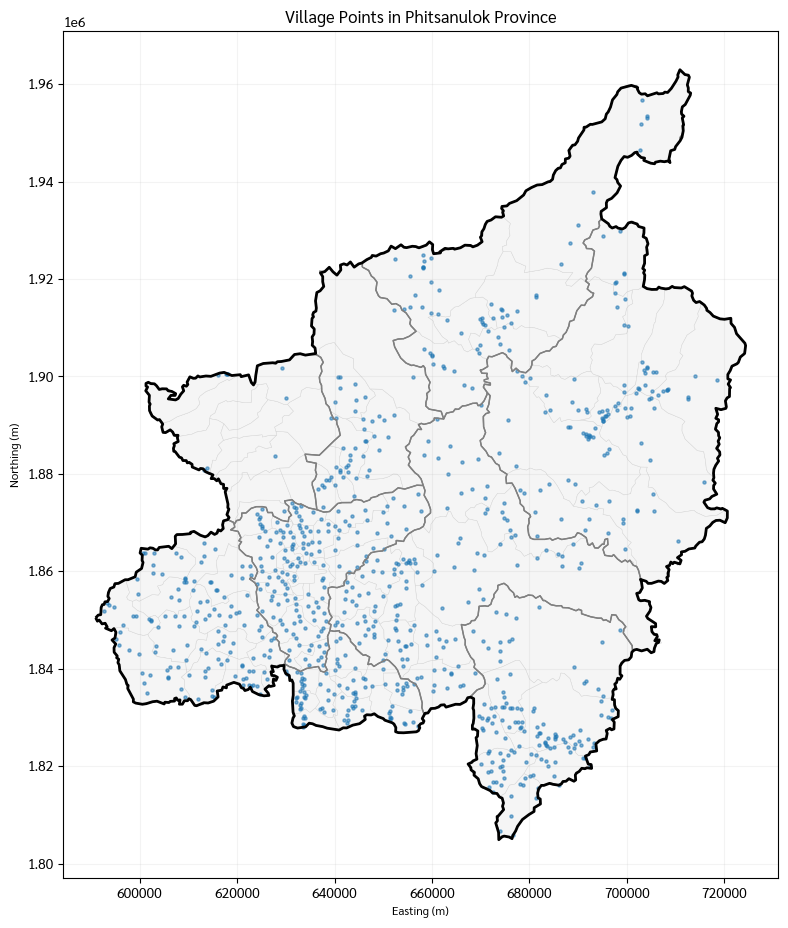

In [38]:
fig_reference, ax = plt.subplots(figsize=(10, 11))

phs_tambon_stats_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.3
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.0
)

phs_village_utm.plot(
    ax=ax,
    markersize=5,
    alpha=0.55
)

ax.set_title("Village Points in Phitsanulok Province")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.grid(alpha=0.15)

plt.show()

## 42. Village Count by Tambon

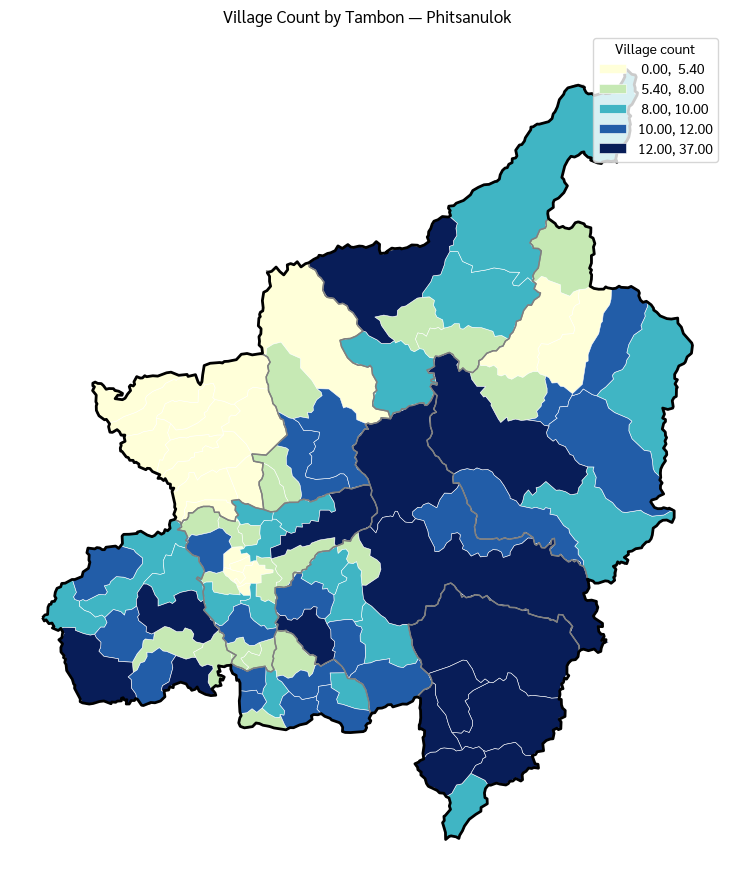

In [39]:
fig_count, ax = plt.subplots(figsize=(10, 11))

phs_tambon_stats_utm.plot(
    ax=ax,
    column="village_count",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"title": "Village count"}
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.0
)

ax.set_title("Village Count by Tambon — Phitsanulok")
ax.set_axis_off()

plt.show()

## 43. Village Density by Tambon

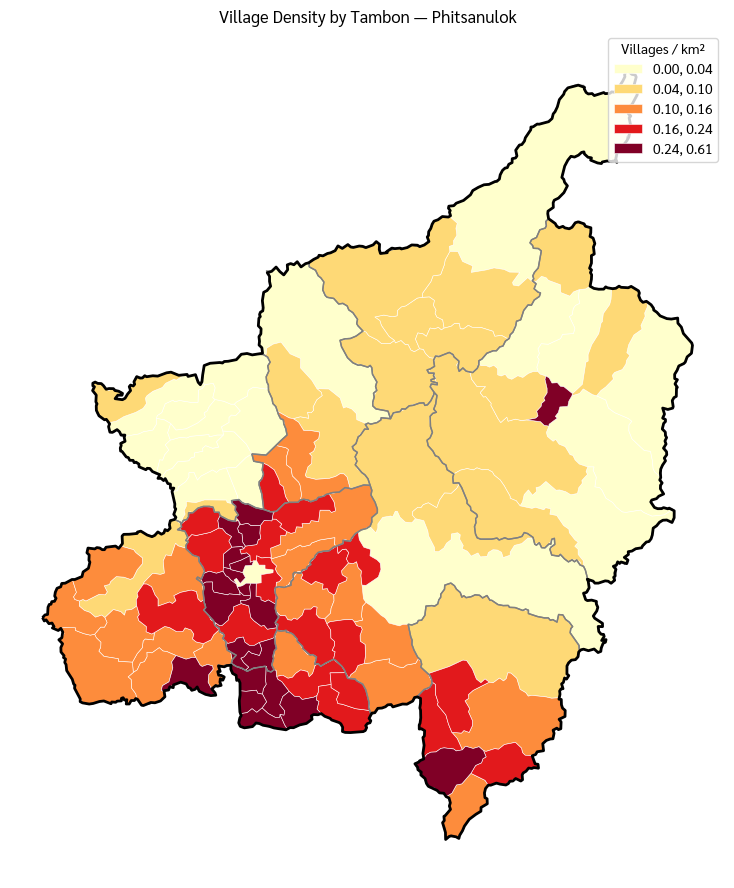

In [40]:
fig_density, ax = plt.subplots(figsize=(10, 11))

phs_tambon_stats_utm.plot(
    ax=ax,
    column="village_density",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={"title": "Villages / km²"}
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.0
)

ax.set_title("Village Density by Tambon — Phitsanulok")
ax.set_axis_off()

plt.show()

เปรียบเทียบสองแผนที่:

```text
Count map
→ where are many village points?

Density map
→ where are village points concentrated relative to area?
```

# Part O — Folium Interactive Village Map

## 44. Safe Web GIS Architecture

ใช้ pattern เดียวกับ Notebook 05 รุ่นแก้ไข:

$$
\boxed{
Full\ GIS
\rightarrow
Compact\ Web\ Layer
\rightarrow
Validated\ GeoJSON
\rightarrow
Folium
}
$$

## 45. JSON-safe helper

In [41]:
def _json_safe_scalar(value):
    if value is None:
        return None

    try:
        if pd.isna(value):
            return None
    except Exception:
        pass

    if isinstance(value, pd.Timestamp):
        return value.isoformat()

    if isinstance(value, np.generic):
        value = value.item()

    if isinstance(value, (str, int, float, bool)):
        return value

    return str(value)


def prepare_web_layer(
    gdf,
    fields,
    code_fields=None,
    numeric_fields=None,
    target_crs="EPSG:4326"
):
    fields = [
        f for f in fields
        if f is not None and f in gdf.columns
    ]

    fields = list(dict.fromkeys(fields))

    web = gdf[
        fields + ["geometry"]
    ].copy()

    web = web.to_crs(target_crs)

    code_fields = code_fields or []
    numeric_fields = numeric_fields or []

    for col in code_fields:
        if col in web.columns:
            web[col] = web[col].map(
                lambda v:
                    None if pd.isna(v) else str(v)
            )

    for col in numeric_fields:
        if col in web.columns:
            web[col] = pd.to_numeric(
                web[col],
                errors="coerce"
            ).astype(float)

    for col in fields:
        if col not in code_fields and col not in numeric_fields:
            web[col] = web[col].map(_json_safe_scalar)

    return gpd.GeoDataFrame(
        web,
        geometry="geometry",
        crs=target_crs
    )


def to_safe_geojson(gdf):
    obj = json.loads(gdf.to_json())
    json.dumps(obj, ensure_ascii=False)
    return obj

## 46. Prepare compact web layers

In [42]:
province_web = prepare_web_layer(
    phs_province_utm,
    fields=[p_adm1_code, p_adm1_th],
    code_fields=[p_adm1_code]
)

district_web = prepare_web_layer(
    phs_district_utm,
    fields=[d_adm1_code, d_adm2_code, d_adm2_th],
    code_fields=[d_adm1_code, d_adm2_code]
)

tambon_web = prepare_web_layer(
    phs_tambon_stats_utm,
    fields=[
        t_adm1_code,
        t_adm1_th,
        t_adm2_code,
        t_adm2_th,
        t_adm3_code,
        t_adm3_th,
        "village_count",
        "area_km2",
        "village_density"
    ],
    code_fields=[
        t_adm1_code,
        t_adm2_code,
        t_adm3_code
    ],
    numeric_fields=[
        "village_count",
        "area_km2",
        "village_density"
    ]
)

village_web_fields = [
    f for f in [
        village_code,
        village_name,
        "SP_ADM1_TH",
        "SP_ADM2_TH",
        "SP_ADM3_TH"
    ]
    if f is not None and f in phs_village_utm.columns
]

village_web = prepare_web_layer(
    phs_village_utm,
    fields=village_web_fields,
    code_fields=[
        f for f in [village_code]
        if f is not None
    ]
)

print("Village web fields:", village_web.columns.tolist())

Village web fields: ['VILL_ID', 'TAM_NAME', 'SP_ADM1_TH', 'SP_ADM2_TH', 'SP_ADM3_TH', 'geometry']


## 47. Validate GeoJSON

In [43]:
province_geojson = to_safe_geojson(province_web)
district_geojson = to_safe_geojson(district_web)
tambon_geojson = to_safe_geojson(tambon_web)
village_geojson = to_safe_geojson(village_web)

for name, obj, gdf in [
    ("Province", province_geojson, province_web),
    ("District", district_geojson, district_web),
    ("Tambon", tambon_geojson, tambon_web),
    ("Village", village_geojson, village_web),
]:
    json.dumps(obj, ensure_ascii=False)
    print(
        f"{name}: GeoJSON serialization OK "
        f"({len(gdf)} features)"
    )

Province: GeoJSON serialization OK (1 features)
District: GeoJSON serialization OK (9 features)
Tambon: GeoJSON serialization OK (93 features)
Village: GeoJSON serialization OK (863 features)


## 48. Basemap helper

In [44]:
def add_basemap(m, provider, name, show=False):
    folium.TileLayer(
        tiles=provider.build_url(),
        attr=provider.html_attribution,
        name=name,
        overlay=False,
        control=True,
        show=show
    ).add_to(m)

## 49. Create map + basemap switcher

In [45]:
center = province_web.geometry.representative_point().iloc[0]

m = folium.Map(
    location=[center.y, center.x],
    zoom_start=8,
    tiles=None,
    control_scale=True
)

add_basemap(
    m,
    xyz.OpenTopoMap,
    "OpenTopoMap",
    show=True
)

add_basemap(
    m,
    xyz.Esri.WorldTopoMap,
    "Esri World Topographic",
    show=False
)

add_basemap(
    m,
    xyz.Esri.WorldImagery,
    "Esri World Imagery (Satellite)",
    show=False
)

## 50. Administrative boundaries

In [46]:
folium.GeoJson(
    province_geojson,
    name="Province boundary",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#000000",
        "weight": 3
    }
).add_to(m)

folium.GeoJson(
    district_geojson,
    name="District boundaries",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#555555",
        "weight": 1.4
    }
).add_to(m)

folium.GeoJson(
    tambon_geojson,
    name="Tambon boundaries",
    style_function=lambda feature: {
        "fillOpacity": 0.0,
        "color": "#999999",
        "weight": 0.6
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            t_adm3_th,
            t_adm2_th,
            "village_count",
            "village_density"
        ],
        aliases=[
            "ตำบล:",
            "อำเภอ:",
            "Village count:",
            "Villages/km²:"
        ],
        localize=True
    )
).add_to(m)

## 51. Village points as CircleMarker

In [47]:
village_group = folium.FeatureGroup(
    name="Village points",
    show=True
)

for _, row in village_web.iterrows():
    details = []

    if village_name and village_name in village_web.columns:
        details.append(
            f"Village: {row[village_name]}"
        )

    if "SP_ADM3_TH" in village_web.columns:
        details.append(
            f"Tambon: {row['SP_ADM3_TH']}"
        )

    if "SP_ADM2_TH" in village_web.columns:
        details.append(
            f"District: {row['SP_ADM2_TH']}"
        )

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=2.5,
        weight=0.5,
        fill=True,
        fill_opacity=0.75,
        tooltip="<br>".join(details)
    ).add_to(village_group)

village_group.add_to(m)

## 52. Village Count Choropleth

In [48]:
count_data = tambon_web[
    [t_adm3_code, "village_count"]
].copy()

folium.Choropleth(
    geo_data=tambon_geojson,
    data=count_data,
    columns=[
        t_adm3_code,
        "village_count"
    ],
    key_on=(
        "feature.properties."
        + t_adm3_code
    ),
    fill_color="YlGnBu",
    fill_opacity=0.58,
    line_opacity=0.3,
    legend_name="Village count",
    name="Village count choropleth",
    show=False
).add_to(m)

## 53. Village Density Choropleth

In [49]:
density_data = tambon_web[
    [t_adm3_code, "village_density"]
].copy()

folium.Choropleth(
    geo_data=tambon_geojson,
    data=density_data,
    columns=[
        t_adm3_code,
        "village_density"
    ],
    key_on=(
        "feature.properties."
        + t_adm3_code
    ),
    fill_color="YlOrRd",
    fill_opacity=0.58,
    line_opacity=0.3,
    legend_name="Villages / km²",
    name="Village density choropleth",
    show=False
).add_to(m)

## 54. Layer Control

In [50]:
folium.LayerControl(
    collapsed=False
).add_to(m)

m

### Visual interpretation with Esri World Imagery

เปิด

```text
Esri World Imagery
+
Village points
+
Tambon boundaries
```

แล้วสังเกต village pattern เทียบกับ settlement, agricultural mosaics, river corridors และ mountainous terrain

> Village point อาจเป็น representative location ไม่ใช่ footprint ของทั้งหมู่บ้าน

# Part P — Publication-quality Maps

## 55. North arrow + scale bar

In [51]:
def add_north_arrow(
    ax,
    x=0.92,
    y=0.10,
    size=0.09
):
    ax.annotate(
        "N",
        xy=(x, y + size),
        xytext=(x, y),
        xycoords=ax.transAxes,
        textcoords=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=1.4,
            color="black"
        )
    )


def choose_scale_m(width_m):
    candidates = np.array([
        5_000, 10_000, 20_000,
        50_000, 100_000, 200_000
    ])

    target = width_m / 4

    return int(
        candidates[
            np.argmin(
                np.abs(candidates - target)
            )
        ]
    )


def add_projected_scalebar(ax):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    width_m = xmax - xmin
    height_m = ymax - ymin
    scale_m = choose_scale_m(width_m)

    x0 = xmin + 0.08 * width_m
    y0 = ymin + 0.06 * height_m
    x1 = x0 + scale_m

    ax.plot(
        [x0, x1],
        [y0, y0],
        color="black",
        linewidth=3
    )

    tick = 0.01 * height_m

    ax.plot(
        [x0, x0],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.plot(
        [x1, x1],
        [y0 - tick, y0 + tick],
        color="black",
        linewidth=1.2
    )

    ax.text(
        (x0 + x1) / 2,
        y0 + 0.02 * height_m,
        f"{scale_m/1000:g} km",
        ha="center",
        va="bottom",
        fontsize=8.5
    )

## 56. Publication Map — Village Points

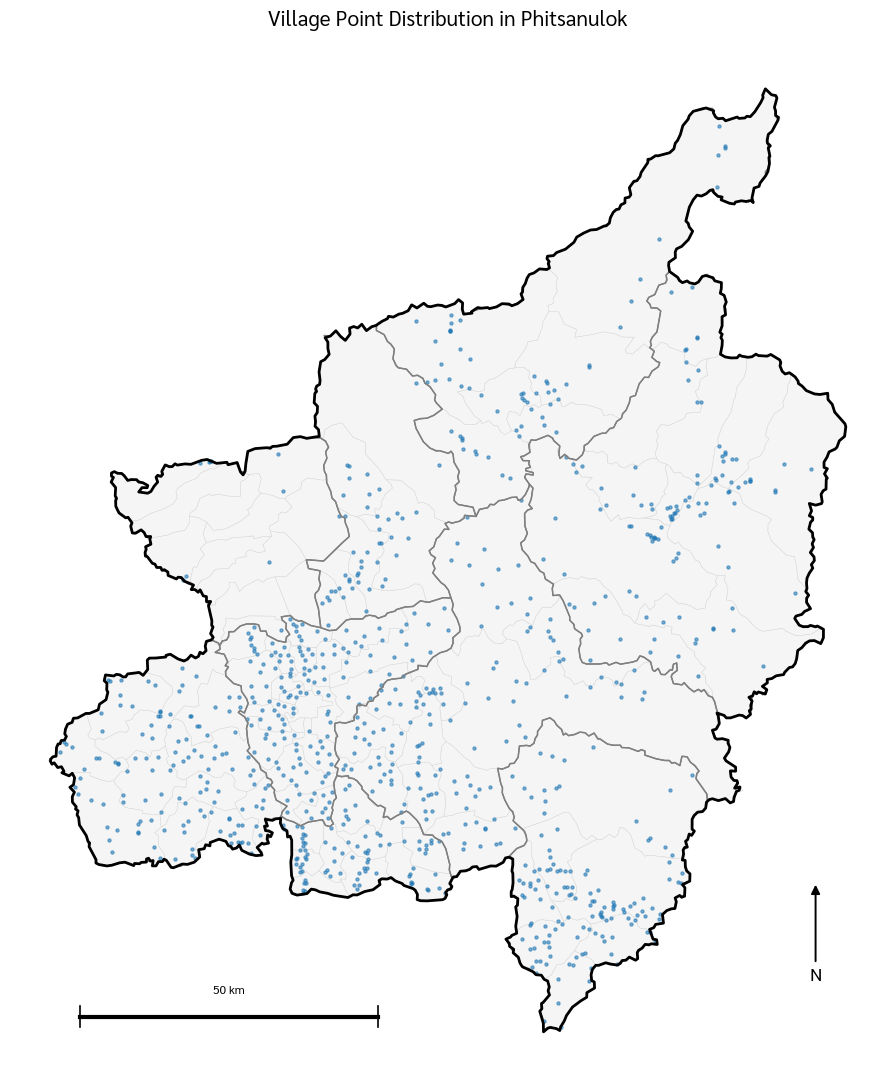

In [52]:
fig_pub_ref, ax = plt.subplots(figsize=(10, 11))

phs_tambon_stats_utm.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.3
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.0
)

phs_village_utm.plot(
    ax=ax,
    markersize=5,
    alpha=0.55
)

ax.set_title(
    "Village Point Distribution in Phitsanulok",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

plt.tight_layout()
plt.show()

## 57. Publication Map — Village Count

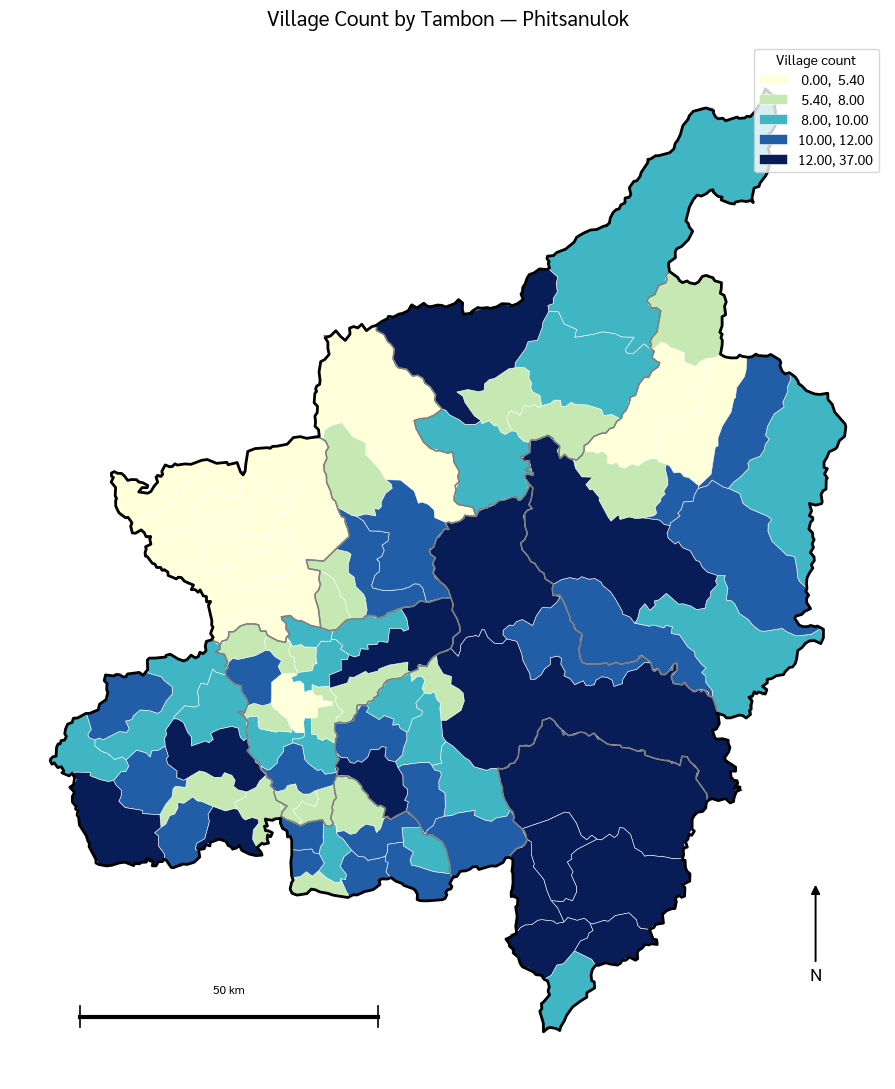

In [53]:
fig_pub_count, ax = plt.subplots(figsize=(10, 11))

phs_tambon_stats_utm.plot(
    ax=ax,
    column="village_count",
    scheme="Quantiles",
    k=5,
    cmap="YlGnBu",
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={
        "title": "Village count"
    }
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.0
)

ax.set_title(
    "Village Count by Tambon — Phitsanulok",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

plt.tight_layout()
plt.show()

## 58. Publication Map — Village Density

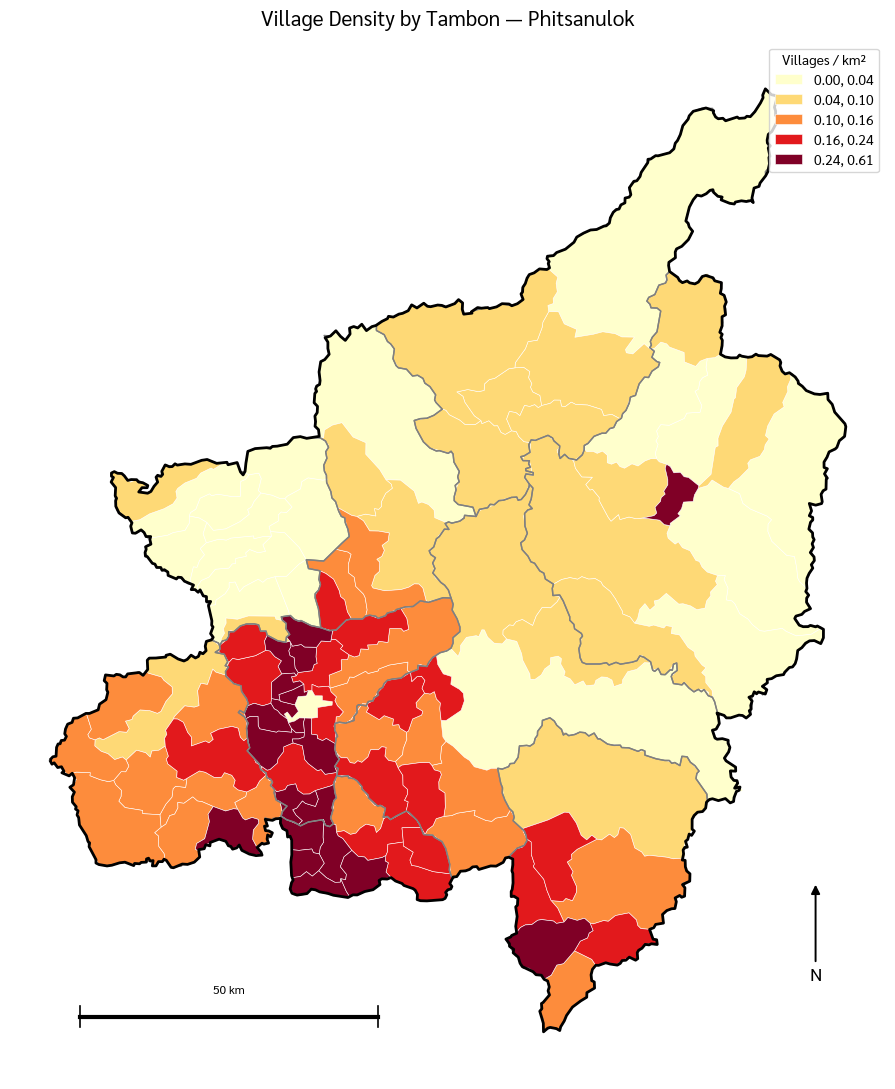

In [54]:
fig_pub_density, ax = plt.subplots(figsize=(10, 11))

phs_tambon_stats_utm.plot(
    ax=ax,
    column="village_density",
    scheme="Quantiles",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor="white",
    linewidth=0.4,
    legend_kwds={
        "title": "Villages / km²"
    }
)

phs_district_utm.boundary.plot(
    ax=ax,
    color="gray",
    linewidth=1.0
)

phs_province_utm.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2.0
)

ax.set_title(
    "Village Density by Tambon — Phitsanulok",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_axis_off()

add_north_arrow(ax)
add_projected_scalebar(ax)

plt.tight_layout()
plt.show()

# Part Q — Export

## 59. Output folders

In [55]:
MAP_DIR = OUTPUT_DIR / "maps"
VECTOR_DIR = OUTPUT_DIR / "vectors"
TABLE_DIR = OUTPUT_DIR / "tables"
HTML_DIR = OUTPUT_DIR / "html"

for folder in [
    MAP_DIR,
    VECTOR_DIR,
    TABLE_DIR,
    HTML_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

## 60. Export PNG 300 dpi

In [56]:
fig_pub_ref.savefig(
    MAP_DIR / "phitsanulok_village_reference_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_count.savefig(
    MAP_DIR / "phitsanulok_village_count_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

fig_pub_density.savefig(
    MAP_DIR / "phitsanulok_village_density_300dpi.png",
    dpi=300,
    bbox_inches="tight"
)

print("PNG maps exported.")

PNG maps exported.


## 61. Export GeoPackage

In [57]:
villages_gpkg = (
    VECTOR_DIR
    / "phitsanulok_villages_joined.gpkg"
)

if villages_gpkg.exists():
    villages_gpkg.unlink()

phs_village_utm.to_file(
    villages_gpkg,
    layer="villages_joined",
    driver="GPKG"
)

tambon_gpkg = (
    VECTOR_DIR
    / "phitsanulok_tambon_village_stats.gpkg"
)

if tambon_gpkg.exists():
    tambon_gpkg.unlink()

phs_tambon_stats_utm.to_file(
    tambon_gpkg,
    layer="tambon_village_stats",
    driver="GPKG"
)

print("Saved:", villages_gpkg)
print("Saved:", tambon_gpkg)

Saved: /content/gis06_outputs/vectors/phitsanulok_villages_joined.gpkg
Saved: /content/gis06_outputs/vectors/phitsanulok_tambon_village_stats.gpkg


## 62. Export Village Shapefile ZIP

In [58]:
shp_folder = (
    VECTOR_DIR
    / "phitsanulok_villages_shp"
)

if shp_folder.exists():
    shutil.rmtree(shp_folder)

shp_folder.mkdir(
    parents=True,
    exist_ok=True
)

shp_path = (
    shp_folder
    / "phitsanulok_villages.shp"
)

export_fields = [
    f for f in [
        village_code,
        village_name,
        "SP_ADM1_TH",
        "SP_ADM2_TH",
        "SP_ADM3_TH"
    ]
    if f is not None
    and f in phs_village_utm.columns
]

village_export = phs_village_utm[
    export_fields + ["geometry"]
].copy()

village_export.to_file(
    shp_path,
    driver="ESRI Shapefile",
    encoding="UTF-8"
)

village_zip = shutil.make_archive(
    str(
        VECTOR_DIR
        / "phitsanulok_villages"
    ),
    "zip",
    root_dir=shp_folder
)

print("Saved:", village_zip)

Saved: /content/gis06_outputs/vectors/phitsanulok_villages.zip


## 63. Export CSV tables

In [59]:
village_count_tambon.to_csv(
    TABLE_DIR / "village_count_by_tambon.csv",
    index=False,
    encoding="utf-8-sig"
)

village_count_district.to_csv(
    TABLE_DIR / "village_count_by_district.csv",
    index=False,
    encoding="utf-8-sig"
)

phs_tambon_stats[
    [
        t_adm1_th,
        t_adm2_th,
        t_adm3_th,
        "village_count",
        "area_km2",
        "village_density"
    ]
].to_csv(
    TABLE_DIR / "phitsanulok_village_density_by_tambon.csv",
    index=False,
    encoding="utf-8-sig"
)

if not validation_table.empty:
    validation_table.to_csv(
        TABLE_DIR / "spatial_join_validation.csv",
        index=False,
        encoding="utf-8-sig"
    )

print("CSV tables exported.")

CSV tables exported.


## 64. Export Folium HTML

In [60]:
html_path = (
    HTML_DIR
    / "phitsanulok_village_interactive.html"
)

m.save(html_path)

print("Saved:", html_path)

Saved: /content/gis06_outputs/html/phitsanulok_village_interactive.html


## 65. Inspect outputs

In [61]:
for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print(
            p.relative_to(OUTPUT_DIR),
            f"({p.stat().st_size/1024:,.1f} KB)"
        )

html/phitsanulok_village_interactive.html (1,412.3 KB)
maps/phitsanulok_village_count_300dpi.png (705.1 KB)
maps/phitsanulok_village_density_300dpi.png (676.1 KB)
maps/phitsanulok_village_reference_300dpi.png (799.6 KB)
tables/phitsanulok_village_density_by_tambon.csv (10.6 KB)
tables/spatial_join_validation.csv (0.1 KB)
tables/village_count_by_district.csv (55.9 KB)
tables/village_count_by_tambon.csv (650.1 KB)
vectors/phitsanulok_tambon_village_stats.gpkg (200.0 KB)
vectors/phitsanulok_villages.zip (22.8 KB)
vectors/phitsanulok_villages_joined.gpkg (384.0 KB)
vectors/phitsanulok_villages_shp/phitsanulok_villages.cpg (0.0 KB)
vectors/phitsanulok_villages_shp/phitsanulok_villages.dbf (278.3 KB)
vectors/phitsanulok_villages_shp/phitsanulok_villages.prj (0.4 KB)
vectors/phitsanulok_villages_shp/phitsanulok_villages.shp (23.7 KB)
vectors/phitsanulok_villages_shp/phitsanulok_villages.shx (6.8 KB)


# Concept Check

1. Point geometry ต่างจาก polygon อย่างไร?
2. ทำไมชื่อหมู่บ้านจึงไม่ใช่ unique identifier โดยอัตโนมัติ?
3. Point-in-polygon หมายถึงอะไร?
4. Spatial join เปลี่ยน location ให้เป็น attributes ได้อย่างไร?
5. ทำไม village points บางจุดอาจไม่ถูก assign เข้า Tambon?
6. Village count ต่างจาก population อย่างไร?
7. Village count ต่างจาก village density อย่างไร?
8. ทำไม count map และ density map จึงอาจให้ pattern ต่างกัน?
9. ทำไม Web GIS ควรใช้ compact web layer?
10. Esri World Imagery ช่วย interpretation อย่างไร และไม่ได้ทำอะไรโดยอัตโนมัติ?

# Exercise 1 — Top 10 Districts by Village Count

ทำ workflow:

```text
groupby ADM2
↓
count
↓
rank
↓
bar chart
↓
map
```

# Exercise 2 — Top 10 Tambons by Village Density

ในพิษณุโลก:

1. หา Top 10 ด้วย `village_density`
2. แสดง count, area และ density ในตารางเดียวกัน
3. ตรวจว่าตำบล density สูงมี count สูงด้วยหรือไม่

# Exercise 3 — Count vs Density

เลือกอย่างน้อย 3 ตำบลเพื่ออธิบายว่า

$$
Count \neq Density
$$

สร้างตาราง:

```text
Tambon
Village count
Area km²
Village density
```

# Exercise 4 — จังหวัดอื่น

เลือกเชียงใหม่ นครราชสีมา หรือสุราษฎร์ธานี แล้วทำ:

```text
Village points
↓
Spatial join to Tambon
↓
Count
↓
Density
↓
Static maps
↓
Folium
```

# Exercise 5 — Visual Interpretation with Esri World Imagery

เปิด

```text
Esri World Imagery
+
Village points
+
Tambon boundaries
```

เปรียบเทียบ village pattern ในพื้นที่ urban, agricultural และ mountainous

> ห้ามสรุป population จากจำนวน village points

# MSc Challenge — Intro to MAUP

Aggregate village points สองระดับ:

```text
Tambon
vs
District
```

สร้าง village-density choropleth ที่ทั้งสองระดับ แล้วอภิปราย:

> ทำไม spatial pattern เปลี่ยนเมื่อเปลี่ยนหน่วยพื้นที่วิเคราะห์?

นี่เป็นแนวคิดเบื้องต้นของ **Modifiable Areal Unit Problem (MAUP)**

# Summary

Notebook 06 เปลี่ยนจาก polygon analysis ไปสู่ point-based GIS workflow

$$
\boxed{
Point
\rightarrow
Spatial\ Join
\rightarrow
Administrative\ Unit
\rightarrow
Aggregation
\rightarrow
Density
}
$$

สิ่งที่ต้องจำ:

> **Name ≠ Unique ID**

> **Village count ≠ Population**

> **Count ≠ Density**

> **Analysis dataset ≠ Web display dataset**

> **Location can be used to derive attributes**

## ต่อไป: Notebook 07

**Distance, Centroid, Buffer & Concentric-Ring Analysis**

คำถามเปิดบท:

> ถ้าเริ่มจากศูนย์กลางอำเภอเมืองพิษณุโลก เราจะวัดระยะ สร้าง buffer ทุก 20 km และนับหมู่บ้านสะสมถึง 200 km ได้อย่างไร?